# Analisis: Q-Learning (Off-Policy TD Control)

**Estudiante:** Tomas Acosta Bernal
**Codigo:** 202011237

---

## Introduccion

En este analisis implementamos y evaluamos el algoritmo de **Q-Learning**, un metodo de control TD **off-policy**. A diferencia de SARSA (on-policy), Q-Learning actualiza los Q-valores usando el maximo sobre las acciones del siguiente estado, independientemente de la accion que realmente se tome:

$$Q(s,a) \leftarrow (1-\alpha) \cdot Q(s,a) + \alpha \left[ R + \gamma \cdot \max_{a'} Q(s', a') \right]$$

El algoritmo se evalua en tres escenarios:
1. **Cliff-Walk** - Comparacion directa con SARSA
2. **Locked-Door** - Ambiente con sub-objetivos (recoger bola, llave, abrir puerta)
3. **Pruebas de adaptabilidad** - Inicio aleatorio y llaves en posiciones aleatorias

**Implementacion:**
- `q_learning.py` - Agente Q-Learning con metodos `run`, `step`, `get_reward`
- `cliff_walk_environment.py` - Ambiente Cliff-Walk
- `locked_door_environment.py` - Ambiente Locked-Door
- `locked_door_extended.py` - Ambiente Locked-Door extendido (Task 3)

In [21]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '../CLASE_6')

from cliff_walk_environment import CliffWalk
from q_learning import QLearning
from sarsa_agent import SARSA

def print_policy_grid(env, policy):
    arrows = {'up': '  UP  ', 'down': ' DOWN ', 'left': ' LEFT ', 'right': 'RIGHT '}
    for r in range(env.nrows):
        row_str = ""
        for c in range(env.ncols):
            state = (r, c)
            if state == env.goal:
                row_str += " GOAL "
            elif state in env.cliff:
                row_str += " XXXX "
            else:
                row_str += arrows.get(policy.get(state, '?'), '  ?   ')
        print(row_str)

---
# Task 1: Q-Learning en Cliff-Walk
---

## Descripcion del ambiente

Cliff-Walk es una grilla de 6x12 con un barranco a lo largo de la fila inferior. El agente comienza en la esquina inferior izquierda `(5,0)` y debe llegar a la esquina inferior derecha `(5,11)`.

- Recompensa por caer al barranco: **-100** (reset al inicio)
- Recompensa por cada paso: **-1**
- Acciones: **deterministas**

![cliff-walk](img/cliff-walk.png)

## Entrenamiento SARSA vs Q-Learning

In [22]:
np.random.seed(42)

# --- Entrenar SARSA ---
env_sarsa = CliffWalk()
sarsa_agent = SARSA(env_sarsa, epsilon=0.9, gamma=0.96, alpha=0.81)
sarsa_rewards = sarsa_agent.train(num_episodes=2000)

# --- Entrenar Q-Learning ---
env_ql = CliffWalk()
ql_agent = QLearning(env_ql, alpha=0.81, gamma=0.96, epsilon=0.9, num_episodes=2000)
ql_rewards = ql_agent.run()

print("Ambiente Cliff-Walk:")
env_ql.print_grid()

2026-03-25 20:25:16.780 | INFO     | sarsa_agent:train:99 - Episode 100/2000 - Avg Reward (last 100): -71.0 - Steps: 28
2026-03-25 20:25:16.797 | INFO     | sarsa_agent:train:99 - Episode 200/2000 - Avg Reward (last 100): -37.0 - Steps: 34
2026-03-25 20:25:16.809 | INFO     | sarsa_agent:train:99 - Episode 300/2000 - Avg Reward (last 100): -31.9 - Steps: 27
2026-03-25 20:25:16.824 | INFO     | sarsa_agent:train:99 - Episode 400/2000 - Avg Reward (last 100): -31.3 - Steps: 40
2026-03-25 20:25:16.874 | INFO     | sarsa_agent:train:99 - Episode 500/2000 - Avg Reward (last 100): -108.6 - Steps: 31
2026-03-25 20:25:16.908 | INFO     | sarsa_agent:train:99 - Episode 600/2000 - Avg Reward (last 100): -73.8 - Steps: 61
2026-03-25 20:25:16.931 | INFO     | sarsa_agent:train:99 - Episode 700/2000 - Avg Reward (last 100): -49.6 - Steps: 21
2026-03-25 20:25:16.951 | INFO     | sarsa_agent:train:99 - Episode 800/2000 - Avg Reward (last 100): -46.2 - Steps: 43
2026-03-25 20:25:16.982 | INFO     | sa

Ambiente Cliff-Walk:
 -  -  -  -  -  -  -  -  -  -  -  - 
 -  -  -  -  -  -  -  -  -  -  -  - 
 -  -  -  -  -  -  -  -  -  -  -  - 
 -  -  -  -  -  -  -  -  -  -  -  - 
 -  -  -  -  -  -  -  -  -  -  -  - 
 S  X  X  X  X  X  X  X  X  X  X  G 



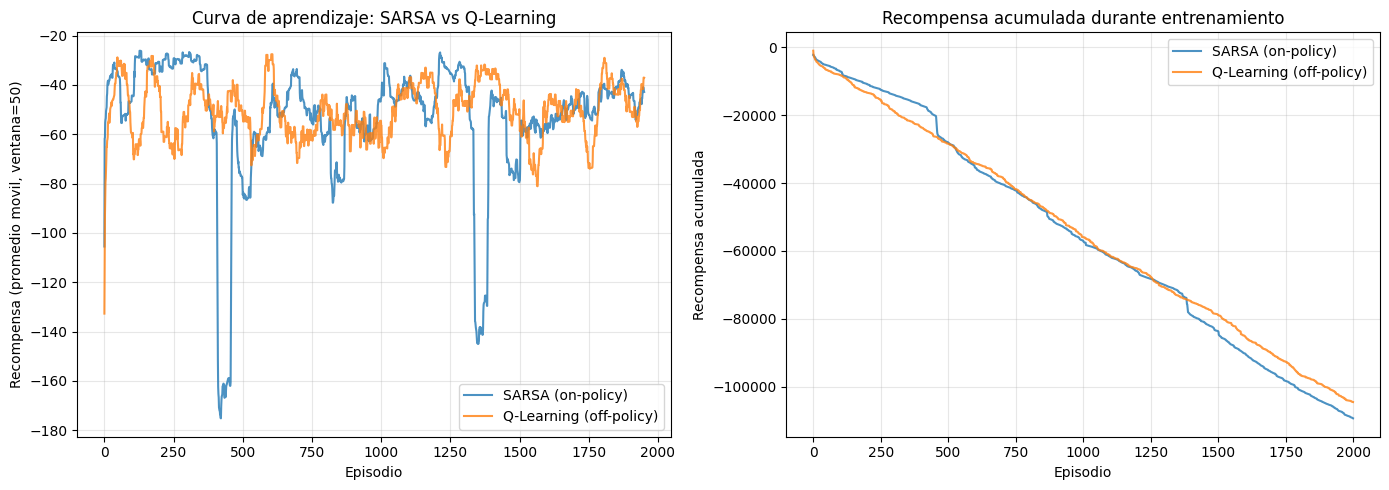

SARSA  - Recompensa promedio (ultimos 100): -43.5
Q-Learn - Recompensa promedio (ultimos 100): -44.0


In [23]:
# --- Curvas de aprendizaje ---
def moving_average(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recompensa por episodio (promedio movil)
ax1 = axes[0]
ax1.plot(moving_average(sarsa_rewards, 50), label='SARSA (on-policy)', alpha=0.8)
ax1.plot(moving_average(ql_rewards, 50), label='Q-Learning (off-policy)', alpha=0.8)
ax1.set_xlabel('Episodio')
ax1.set_ylabel('Recompensa (promedio movil, ventana=50)')
ax1.set_title('Curva de aprendizaje: SARSA vs Q-Learning')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Recompensa acumulada
ax2 = axes[1]
ax2.plot(np.cumsum(sarsa_rewards), label='SARSA (on-policy)', alpha=0.8)
ax2.plot(np.cumsum(ql_rewards), label='Q-Learning (off-policy)', alpha=0.8)
ax2.set_xlabel('Episodio')
ax2.set_ylabel('Recompensa acumulada')
ax2.set_title('Recompensa acumulada durante entrenamiento')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"SARSA  - Recompensa promedio (ultimos 100): {np.mean(sarsa_rewards[-100:]):.1f}")
print(f"Q-Learn - Recompensa promedio (ultimos 100): {np.mean(ql_rewards[-100:]):.1f}")

## Comparacion de politicas aprendidas

In [24]:
# --- Politicas aprendidas ---
print("Politica SARSA (on-policy):")
sarsa_policy = sarsa_agent.get_policy()
print_policy_grid(env_sarsa, sarsa_policy)

print("\nPolitica Q-Learning (off-policy):")
ql_policy = ql_agent.get_policy()
print_policy_grid(env_ql, ql_policy)

# --- Trayectorias greedy ---
print("\nTrayectoria greedy SARSA:")
sarsa_agent.epsilon = 1.0
env_sarsa.reset()
sarsa_path = [env_sarsa.get_current_state()]
steps_s = 0
while not env_sarsa.is_terminal() and steps_s < 100:
    state = env_sarsa.get_current_state()
    action = sarsa_agent.choose_action(state)
    _, ns = env_sarsa.do_action(action)
    sarsa_path.append(ns)
    steps_s += 1
env_sarsa.print_grid(path=set(sarsa_path))
print(f"Longitud SARSA: {len(sarsa_path) - 1} pasos")

print("Trayectoria greedy Q-Learning:")
ql_path = ql_agent.print_path()
print(f"Longitud Q-Learning: {len(ql_path) - 1} pasos")

Politica SARSA (on-policy):
RIGHT RIGHT RIGHT RIGHT  DOWN RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT  DOWN 
  UP    UP   LEFT   UP  RIGHT   UP   LEFT   UP    UP   DOWN RIGHT  DOWN 
RIGHT   UP  RIGHT RIGHT   UP    UP  RIGHT   UP   LEFT   UP  RIGHT  DOWN 
RIGHT   UP  RIGHT   UP    UP  RIGHT  DOWN   UP  RIGHT RIGHT RIGHT  DOWN 
  UP    UP    UP    UP   LEFT RIGHT RIGHT   UP    UP    UP    UP   DOWN 
  UP   XXXX  XXXX  XXXX  XXXX  XXXX  XXXX  XXXX  XXXX  XXXX  XXXX  GOAL 

Politica Q-Learning (off-policy):
  UP  RIGHT RIGHT  LEFT RIGHT  LEFT RIGHT  DOWN  DOWN RIGHT RIGHT  DOWN 
 LEFT RIGHT RIGHT   UP   DOWN  DOWN  DOWN RIGHT RIGHT  DOWN RIGHT  DOWN 
  UP  RIGHT   UP  RIGHT RIGHT  DOWN RIGHT  DOWN RIGHT RIGHT  DOWN  DOWN 
 DOWN  DOWN  DOWN  DOWN  DOWN  DOWN  DOWN  DOWN  DOWN  DOWN  DOWN  DOWN 
RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT  DOWN 
  UP   XXXX  XXXX  XXXX  XXXX  XXXX  XXXX  XXXX  XXXX  XXXX  XXXX  GOAL 

Trayectoria greedy SARSA:
 -  .  .  .  .  .  .  .  .  .  .  

## Analisis - Task 1: Diferencias entre SARSA y Q-Learning

| Aspecto | SARSA (on-policy) | Q-Learning (off-policy) |
|---------|-------------------|------------------------|
| **Regla de actualizacion** | $Q(s,a) \leftarrow ... + \alpha[\gamma \cdot Q(s', a')]$ donde $a'$ es la accion que **realmente se toma** | $Q(s,a) \leftarrow ... + \alpha[\gamma \cdot \max_{a'} Q(s', a')]$ usa el **maximo** sobre acciones |
| **Camino aprendido** | Seguro, alejado del barranco | Optimo, al borde del barranco |
| **Longitud del camino greedy** | ~17+ pasos (rodea por arriba) | ~13 pasos (fila 4, justo arriba del barranco) |
| **Recompensa durante entrenamiento** | Mejor (camino seguro, menos caidas) | Peor (camino al borde, exploracion lo mata) |
| **Recompensa en explotacion** | Peor (camino mas largo) | Mejor (camino mas corto) |

**Observaciones:**

1. **Q-Learning aprende el camino optimo** (fila 4, justo encima del barranco). Esto ocurre porque Q-Learning es off-policy: usa $\max Q(s', a')$ para actualizar, lo cual representa el valor de la mejor accion posible, no la accion que realmente se toma durante exploracion.

2. **SARSA aprende un camino seguro** (filas superiores, lejos del barranco). SARSA es on-policy: actualiza con $Q(s', a')$ donde $a'$ es la accion que realmente se elige. Como el agente explora con probabilidad $1-\epsilon$, hay riesgo de caer al barranco al estar cerca de el, y SARSA incorpora ese riesgo en sus Q-valores.

3. **Durante entrenamiento** (con exploracion), SARSA obtiene mejor recompensa promedio porque su politica es mas segura. Q-Learning obtiene peor recompensa durante entrenamiento porque su politica greedy lo lleva al borde del barranco donde la exploracion aleatoria lo puede matar.

4. **En explotacion** (sin exploracion, $\epsilon = 1$), Q-Learning es superior porque su camino es mas corto y directo.

5. **Implicacion practica:** Si las consecuencias de la exploracion importan (e.g., un robot fisico), SARSA es preferible. Si solo importa la politica final, Q-Learning encuentra la optima.

---
# Task 2: Locked-Door
---

## Descripcion del ambiente

El ambiente consiste en dos habitaciones (4x9) separadas por una pared con una puerta cerrada con llave. El agente debe:
1. Recoger la **bola** que bloquea la puerta
2. Recoger la **llave** (del mismo color de la puerta)
3. **Abrir la puerta** (estando adyacente, con bola y llave)
4. Navegar hasta el **objetivo** en la habitacion derecha

![locked-door](img/locked-door.png)

**Estado:** `(fila, columna, tiene_bola, tiene_llave, puerta_abierta)`

**Acciones:** `up, down, left, right, pick_up, open_door`

### Sistema de recompensas

| Evento | Recompensa |
|--------|-----------|
| Llegar al objetivo | +100 |
| Recoger bola | +10 |
| Recoger llave correcta | +10 |
| Abrir la puerta | +20 |
| Cada paso / accion invalida | -1 |

Las recompensas intermedias (+10, +20) son fundamentales para guiar al agente hacia los sub-objetivos necesarios. Sin ellas, el agente tendria que descubrir una secuencia larga de acciones correctas antes de recibir cualquier senal positiva.

In [25]:
from locked_door_environment import LockedDoorEnv

env_ld = LockedDoorEnv()
print("Ambiente Locked-Door:")
print("A=Agente, K=Llave, B=Bola, D=Puerta, G=Meta, |=Pared")
env_ld.print_grid()
print(f"Espacio de estados: {len(env_ld.get_states())}")
print(f"Acciones: {env_ld.actions}")

Ambiente Locked-Door:
A=Agente, K=Llave, B=Bola, D=Puerta, G=Meta, |=Pared
Agent: (0,0) | Ball: (2, 4) | Key: (4, 3) | Door: LOCKED
 A  -  -  -  -  |  -  -  -  -  - 
 -  -  -  -  -  |  -  -  -  -  - 
 -  -  -  -  B  D  -  -  -  -  - 
 -  -  -  -  -  |  -  -  -  -  - 
 -  -  -  K  -  |  -  -  -  -  G 

Espacio de estados: 408
Acciones: ['up', 'down', 'left', 'right', 'pick_up', 'open_door']


## Entrenamiento

In [26]:
np.random.seed(42)
env_ld = LockedDoorEnv()
agent_ld = QLearning(env_ld, alpha=0.1, gamma=0.99, epsilon=0.9, num_episodes=5000)
rewards_ld = agent_ld.run()

# Guardar Q-tabla
agent_ld.save_q_table("q_table_locked_door.json")
print(f"\nRecompensa promedio (ultimos 100): {np.mean(rewards_ld[-100:]):.1f}")

2026-03-25 20:25:18.025 | INFO     | q_learning:run:100 - Episode 100/5000 - Avg Reward (last 100): 42.2 - Steps: 24
2026-03-25 20:25:18.050 | INFO     | q_learning:run:100 - Episode 200/5000 - Avg Reward (last 100): 116.7 - Steps: 24
2026-03-25 20:25:18.073 | INFO     | q_learning:run:100 - Episode 300/5000 - Avg Reward (last 100): 118.0 - Steps: 23
2026-03-25 20:25:18.096 | INFO     | q_learning:run:100 - Episode 400/5000 - Avg Reward (last 100): 118.6 - Steps: 25
2026-03-25 20:25:18.120 | INFO     | q_learning:run:100 - Episode 500/5000 - Avg Reward (last 100): 118.0 - Steps: 30
2026-03-25 20:25:18.143 | INFO     | q_learning:run:100 - Episode 600/5000 - Avg Reward (last 100): 117.7 - Steps: 24
2026-03-25 20:25:18.166 | INFO     | q_learning:run:100 - Episode 700/5000 - Avg Reward (last 100): 118.2 - Steps: 25
2026-03-25 20:25:18.188 | INFO     | q_learning:run:100 - Episode 800/5000 - Avg Reward (last 100): 118.2 - Steps: 25
2026-03-25 20:25:18.211 | INFO     | q_learning:run:100 -


Recompensa promedio (ultimos 100): 118.0


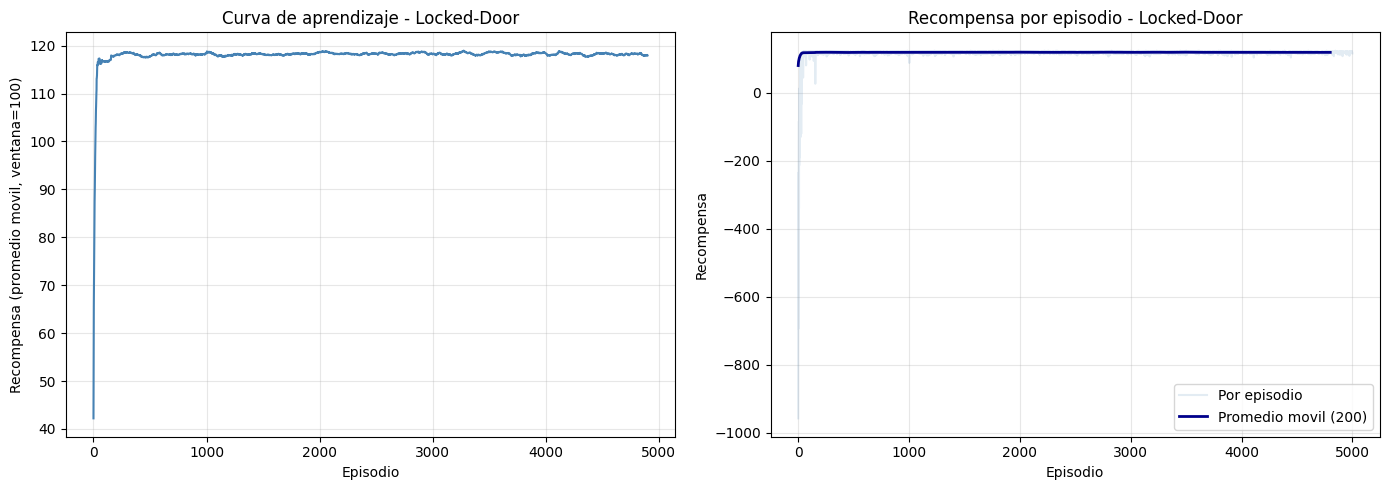

In [27]:
# --- Curva de aprendizaje Locked-Door ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(moving_average(rewards_ld, 100), color='steelblue')
ax1.set_xlabel('Episodio')
ax1.set_ylabel('Recompensa (promedio movil, ventana=100)')
ax1.set_title('Curva de aprendizaje - Locked-Door')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(rewards_ld, alpha=0.15, color='steelblue', label='Por episodio')
ax2.plot(moving_average(rewards_ld, 200), color='darkblue', linewidth=2, label='Promedio movil (200)')
ax2.set_xlabel('Episodio')
ax2.set_ylabel('Recompensa')
ax2.set_title('Recompensa por episodio - Locked-Door')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Explotacion del agente entrenado

In [28]:
# --- Ejecutar un episodio greedy para validar el agente ---
env_ld.reset()
agent_ld.epsilon = 1.0  # greedy
state = env_ld.get_current_state()
steps = 0

print("Ejecucion greedy del agente entrenado:")
print("=" * 65)
while not env_ld.is_terminal() and steps < 50:
    action = agent_ld.choose_action(state)
    reward, new_state = env_ld.do_action(action)
    r, c = new_state[0], new_state[1]
    has_ball, has_key, door_open = new_state[2], new_state[3], new_state[4]
    print(f"  Paso {steps:2d}: {action:10s} -> ({r},{c})  "
          f"bola={'SI' if has_ball else 'no'}  llave={'SI' if has_key else 'no'}  "
          f"puerta={'ABIERTA' if door_open else 'cerrada'}  R={reward:+d}")
    state = new_state
    steps += 1

if env_ld.is_terminal():
    print(f"\nObjetivo alcanzado en {steps} pasos")
else:
    print(f"\nNo se alcanzo el objetivo en {steps} pasos")

Ejecucion greedy del agente entrenado:
  Paso  0: right      -> (0,1)  bola=no  llave=no  puerta=cerrada  R=-1
  Paso  1: down       -> (1,1)  bola=no  llave=no  puerta=cerrada  R=-1
  Paso  2: right      -> (1,2)  bola=no  llave=no  puerta=cerrada  R=-1
  Paso  3: down       -> (2,2)  bola=no  llave=no  puerta=cerrada  R=-1
  Paso  4: right      -> (2,3)  bola=no  llave=no  puerta=cerrada  R=-1
  Paso  5: right      -> (2,4)  bola=no  llave=no  puerta=cerrada  R=-1
  Paso  6: pick_up    -> (2,4)  bola=SI  llave=no  puerta=cerrada  R=+10
  Paso  7: left       -> (2,3)  bola=SI  llave=no  puerta=cerrada  R=-1
  Paso  8: down       -> (3,3)  bola=SI  llave=no  puerta=cerrada  R=-1
  Paso  9: down       -> (4,3)  bola=SI  llave=no  puerta=cerrada  R=-1
  Paso 10: pick_up    -> (4,3)  bola=SI  llave=SI  puerta=cerrada  R=+10
  Paso 11: up         -> (3,3)  bola=SI  llave=SI  puerta=cerrada  R=-1
  Paso 12: right      -> (3,4)  bola=SI  llave=SI  puerta=cerrada  R=-1
  Paso 13: up         -

## Visualizacion de la politica por fase

El estado del agente incluye flags booleanos `(tiene_bola, tiene_llave, puerta_abierta)` que definen **4 fases** del problema. En cada fase, la politica del agente cambia: primero busca la bola, luego la llave, luego abre la puerta, y finalmente navega al objetivo. Los siguientes mapas muestran la accion greedy en cada celda de la grilla para cada fase.

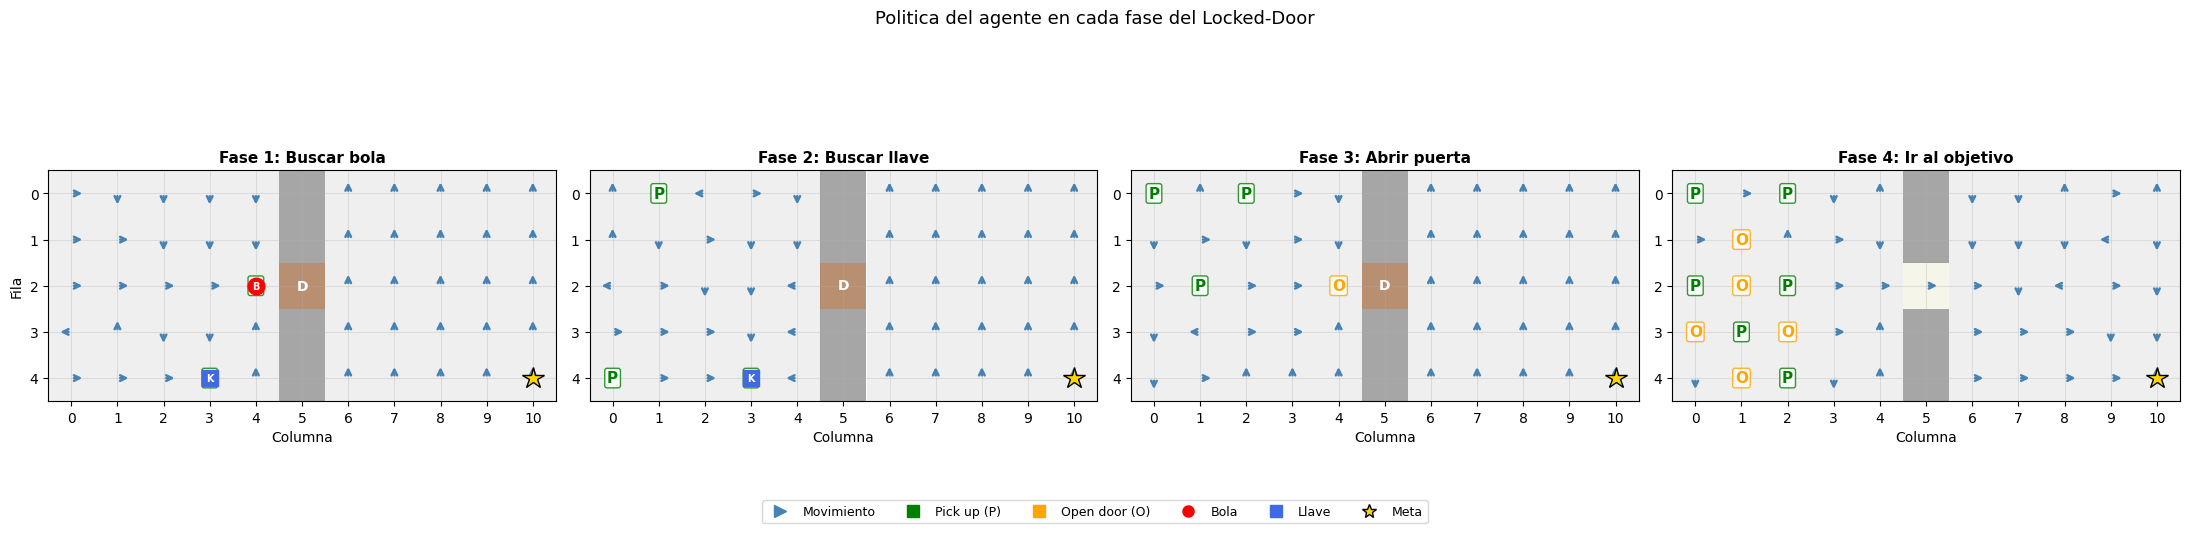

In [29]:
# --- Mapa de politica por fase del Locked-Door ---
phases = [
    ("Fase 1: Buscar bola", False, False, False),
    ("Fase 2: Buscar llave", True, False, False),
    ("Fase 3: Abrir puerta", True, True, False),
    ("Fase 4: Ir al objetivo", True, True, True),
]

# Flechas Unicode para cada accion de movimiento
arrow_map = {
    'up': (0, 0.3),
    'down': (0, -0.3),
    'left': (-0.3, 0),
    'right': (0.3, 0),
    'pick_up': None,
    'open_door': None,
}

# Colores para acciones especiales
action_color = {
    'up': 'steelblue', 'down': 'steelblue', 'left': 'steelblue', 'right': 'steelblue',
    'pick_up': 'green', 'open_door': 'orange',
}
action_label = {'pick_up': 'P', 'open_door': 'O'}

nrows, ncols = env_ld.nrows, env_ld.ncols
wall_col = env_ld.wall_col
door_row = env_ld.door_row

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for idx, (title, has_ball, has_key, door_open) in enumerate(phases):
    ax = axes[idx]

    # Dibujar grilla base
    grid = np.zeros((nrows, ncols))
    for r in range(nrows):
        for c in range(ncols):
            if c == wall_col and not (r == door_row and door_open):
                grid[r][c] = -1  # pared

    ax.imshow(grid, cmap='Greys', vmin=-1, vmax=1, aspect='equal', alpha=0.15)

    # Dibujar pared
    for r in range(nrows):
        if r == door_row:
            if not door_open:
                ax.add_patch(plt.Rectangle((wall_col - 0.5, r - 0.5), 1, 1,
                             facecolor='saddlebrown', alpha=0.6))
                ax.text(wall_col, r, 'D', ha='center', va='center', fontsize=10,
                        fontweight='bold', color='white')
            else:
                ax.add_patch(plt.Rectangle((wall_col - 0.5, r - 0.5), 1, 1,
                             facecolor='lightyellow', alpha=0.4))
        else:
            ax.add_patch(plt.Rectangle((wall_col - 0.5, r - 0.5), 1, 1,
                         facecolor='gray', alpha=0.7))

    # Dibujar objetos
    if not has_ball:
        ax.plot(env_ld.ball_pos[1], env_ld.ball_pos[0], 'o', color='red',
                markersize=12, zorder=5)
        ax.text(env_ld.ball_pos[1], env_ld.ball_pos[0], 'B', ha='center',
                va='center', fontsize=7, fontweight='bold', color='white', zorder=6)
    if not has_key:
        ax.plot(env_ld.key_pos[1], env_ld.key_pos[0], 's', color='royalblue',
                markersize=12, zorder=5)
        ax.text(env_ld.key_pos[1], env_ld.key_pos[0], 'K', ha='center',
                va='center', fontsize=7, fontweight='bold', color='white', zorder=6)
    ax.plot(env_ld.goal_pos[1], env_ld.goal_pos[0], '*', color='gold',
            markersize=16, zorder=5, markeredgecolor='black')

    # Dibujar flechas de politica
    for r in range(nrows):
        for c in range(ncols):
            if c == wall_col and not (r == door_row and door_open):
                continue
            state = (r, c, has_ball, has_key, door_open)
            actions = env_ld.get_possible_actions(state)
            best_action = None
            best_val = float('-inf')
            for a in actions:
                qv = agent_ld.Q.get((state, a), 0.0)
                if qv > best_val:
                    best_val = qv
                    best_action = a

            if best_action is None:
                continue

            color = action_color.get(best_action, 'black')
            delta = arrow_map.get(best_action)
            if delta is not None:
                ax.annotate('', xy=(c + delta[0], r - delta[1]),
                           xytext=(c, r),
                           arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
            else:
                ax.text(c, r, action_label.get(best_action, '?'), ha='center',
                        va='center', fontsize=11, fontweight='bold', color=color,
                        bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                                  edgecolor=color, alpha=0.8))

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(-0.5, ncols - 0.5)
    ax.set_ylim(nrows - 0.5, -0.5)
    ax.set_xticks(range(ncols))
    ax.set_yticks(range(nrows))
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Columna')
    if idx == 0:
        ax.set_ylabel('Fila')

# Leyenda
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='>', color='steelblue', linestyle='None', markersize=8, label='Movimiento'),
    Line2D([0], [0], marker='s', color='green', linestyle='None', markersize=8, label='Pick up (P)'),
    Line2D([0], [0], marker='s', color='orange', linestyle='None', markersize=8, label='Open door (O)'),
    Line2D([0], [0], marker='o', color='red', linestyle='None', markersize=8, label='Bola'),
    Line2D([0], [0], marker='s', color='royalblue', linestyle='None', markersize=8, label='Llave'),
    Line2D([0], [0], marker='*', color='gold', linestyle='None', markersize=10, label='Meta',
           markeredgecolor='black'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=6, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Politica del agente en cada fase del Locked-Door', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

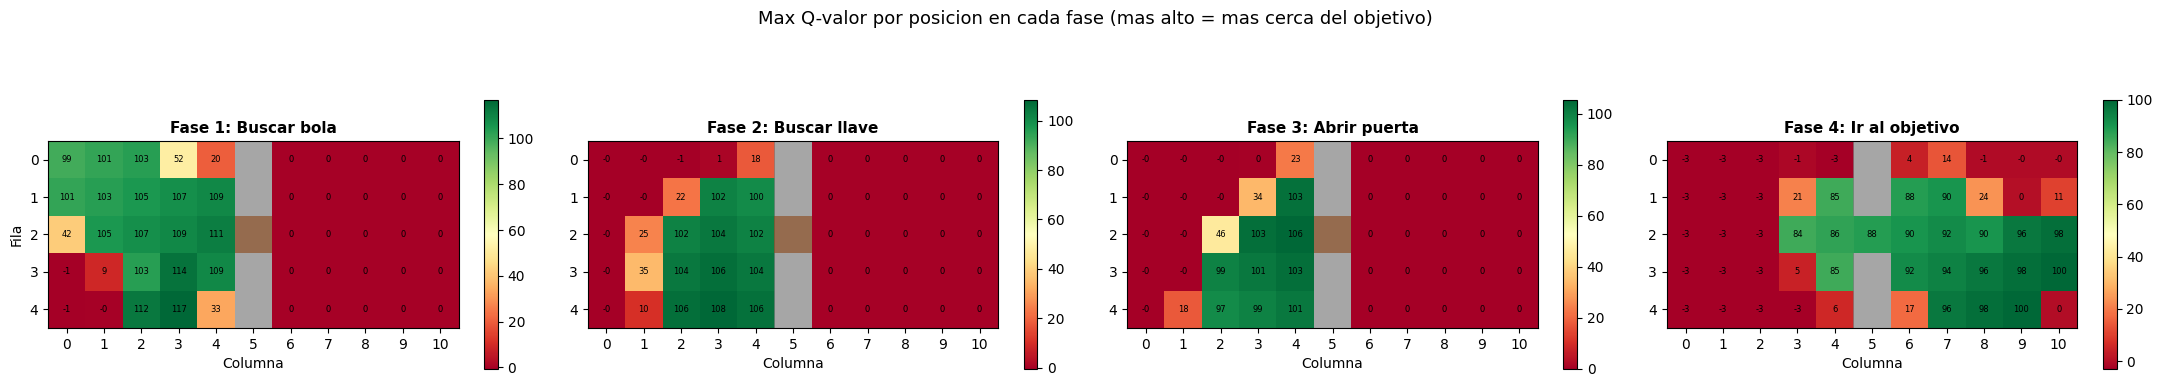

In [30]:
# --- Heatmap de Q-valores maximos por fase ---
fig, axes = plt.subplots(1, 4, figsize=(22, 4))

for idx, (title, has_ball, has_key, door_open) in enumerate(phases):
    ax = axes[idx]
    q_grid = np.full((nrows, ncols), np.nan)

    for r in range(nrows):
        for c in range(ncols):
            if c == wall_col and not (r == door_row and door_open):
                continue
            state = (r, c, has_ball, has_key, door_open)
            actions = env_ld.get_possible_actions(state)
            max_q = max([agent_ld.Q.get((state, a), 0.0) for a in actions], default=0.0)
            q_grid[r][c] = max_q

    im = ax.imshow(q_grid, cmap='RdYlGn', aspect='equal')
    plt.colorbar(im, ax=ax, shrink=0.8)

    # Marcar pared
    for r in range(nrows):
        if c == wall_col and not (r == door_row and door_open):
            pass
        if r != door_row or not door_open:
            ax.add_patch(plt.Rectangle((wall_col - 0.5, r - 0.5), 1, 1,
                         facecolor='gray', alpha=0.7))
        if r == door_row and not door_open:
            ax.add_patch(plt.Rectangle((wall_col - 0.5, r - 0.5), 1, 1,
                         facecolor='saddlebrown', alpha=0.6))

    # Anotar valores en celdas
    for r in range(nrows):
        for c in range(ncols):
            if not np.isnan(q_grid[r][c]):
                ax.text(c, r, f'{q_grid[r][c]:.0f}', ha='center', va='center',
                        fontsize=6, color='black')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(range(ncols))
    ax.set_yticks(range(nrows))
    ax.set_xlabel('Columna')
    if idx == 0:
        ax.set_ylabel('Fila')

plt.suptitle('Max Q-valor por posicion en cada fase (mas alto = mas cerca del objetivo)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Analisis - Task 2

**Observaciones:**

1. El agente aprende exitosamente la secuencia correcta de sub-objetivos:
   - Navegar hasta la **bola** `(3,2)` y recogerla (`pick_up`)
   - Ir hasta la **llave** `(1,3)` y recogerla (`pick_up`)
   - Regresar junto a la **puerta** `(3,3)` y abrirla (`open_door`)
   - Cruzar a la habitacion derecha y navegar hasta el **objetivo** `(0,6)`

2. El **sistema de recompensas intermedias** es clave. Sin las recompensas de +10 por recoger objetos y +20 por abrir la puerta, el agente tendria un problema de recompensa escasa (*sparse reward*): necesitaria completar toda la secuencia antes de recibir cualquier senal positiva, haciendo el aprendizaje extremadamente lento o imposible.

3. La curva de aprendizaje muestra convergencia progresiva: inicialmente el agente obtiene recompensas muy negativas (exploracion sin rumbo), y gradualmente aprende a completar los sub-objetivos.

4. La Q-tabla fue guardada en `q_table_locked_door.json` para su reutilizacion.

---
# Task 3: Pruebas de adaptabilidad
---

## Escenario 3.1: Punto de inicio aleatorio

Primero probamos el agente original (entrenado desde posicion fija `(2,0)`) en posiciones de inicio aleatorias para demostrar la limitacion. Luego entrenamos un nuevo agente con inicio aleatorio como solucion.

In [31]:
# --- Prueba: agente original en posiciones aleatorias ---
print("=== Prueba: agente original (entrenado desde (2,0)) en posiciones aleatorias ===")
print()

test_starts = [(2, 0), (0, 0), (3, 3), (1, 1), (0, 3), (3, 0)]
results_original = []
for start in test_starts:
    env_ld.agent_start = start
    env_ld.reset()
    env_ld.current_state = (start[0], start[1], False, False, False)
    agent_ld.epsilon = 1.0
    state = env_ld.get_current_state()
    steps = 0
    while not env_ld.is_terminal() and steps < 50:
        action = agent_ld.choose_action(state)
        _, new_state = env_ld.do_action(action)
        state = new_state
        steps += 1
    reached = env_ld.is_terminal()
    results_original.append(reached)
    print(f"  Inicio {start}: {'EXITO' if reached else 'FALLO'} en {steps} pasos")

# Restaurar
env_ld.agent_start = (2, 0)

=== Prueba: agente original (entrenado desde (2,0)) en posiciones aleatorias ===

  Inicio (2, 0): EXITO en 21 pasos
  Inicio (0, 0): EXITO en 23 pasos
  Inicio (3, 3): EXITO en 15 pasos
  Inicio (1, 1): EXITO en 21 pasos
  Inicio (0, 3): EXITO en 20 pasos
  Inicio (3, 0): FALLO en 50 pasos


### Solucion 3.1: Entrenar con inicio aleatorio

In [32]:
# --- Solucion: entrenar con posiciones de inicio aleatorias ---
np.random.seed(42)
left_room = [(r, c) for r in range(4) for c in range(4)]
env_rand = LockedDoorEnv()

agent_rand = QLearning(env_rand, alpha=0.1, gamma=0.99, epsilon=0.9, num_episodes=10000)

rewards_rand = []
for ep in range(10000):
    start = left_room[np.random.randint(len(left_room))]
    env_rand.agent_start = start
    env_rand.reset()

    state = env_rand.get_current_state()
    total_reward = 0
    steps = 0

    while not env_rand.is_terminal() and steps < 200:
        action = agent_rand.choose_action(state)
        reward, done, new_state = agent_rand.step(action)
        total_reward += reward

        actions_next = env_rand.get_possible_actions(new_state)
        max_q = max([agent_rand.Q.get((new_state, a), 0.0) for a in actions_next], default=0.0)
        old_q = agent_rand.Q.get((state, action), 0.0)
        agent_rand.Q[(state, action)] = (1 - agent_rand.alpha) * old_q + \
                                         agent_rand.alpha * (reward + agent_rand.gamma * max_q)
        state = new_state
        steps += 1

    rewards_rand.append(total_reward)
    if (ep + 1) % 2000 == 0:
        print(f"  Episodio {ep+1}/10000 - Avg reward (ult 100): {np.mean(rewards_rand[-100:]):.1f}")

agent_rand.save_q_table("q_table_random_start.json")

  Episodio 2000/10000 - Avg reward (ult 100): 121.5
  Episodio 4000/10000 - Avg reward (ult 100): 124.0
  Episodio 6000/10000 - Avg reward (ult 100): 123.5
  Episodio 8000/10000 - Avg reward (ult 100): 123.1
  Episodio 10000/10000 - Avg reward (ult 100): 123.3


2026-03-25 20:25:24.621 | INFO     | q_learning:save_q_table:128 - Q-table saved to q_table_random_start.json


In [33]:
# --- Comparacion: agente original vs agente con inicio aleatorio ---
print("Evaluacion comparativa:")
print("=" * 65)
print(f"{'Inicio':<12} {'Original (fijo)':>18} {'Nuevo (aleatorio)':>20}")
print("-" * 65)

results_rand = []
for start in test_starts:
    env_rand.agent_start = start
    env_rand.reset()
    env_rand.current_state = (start[0], start[1], False, False, False)
    agent_rand.epsilon = 1.0
    state = env_rand.get_current_state()
    steps = 0
    while not env_rand.is_terminal() and steps < 50:
        action = agent_rand.choose_action(state)
        _, new_state = env_rand.do_action(action)
        state = new_state
        steps += 1
    reached = env_rand.is_terminal()
    results_rand.append((reached, steps))

for i, start in enumerate(test_starts):
    orig = 'EXITO' if results_original[i] else 'FALLO'
    new_reached, new_steps = results_rand[i]
    new_res = f"EXITO ({new_steps} pasos)" if new_reached else 'FALLO'
    print(f"  {str(start):<12} {orig:>18} {new_res:>20}")

Evaluacion comparativa:
Inicio          Original (fijo)    Nuevo (aleatorio)
-----------------------------------------------------------------
  (2, 0)                    EXITO     EXITO (19 pasos)
  (0, 0)                    EXITO     EXITO (21 pasos)
  (3, 3)                    EXITO     EXITO (15 pasos)
  (1, 1)                    EXITO     EXITO (19 pasos)
  (0, 3)                    EXITO     EXITO (18 pasos)
  (3, 0)                    FALLO     EXITO (20 pasos)


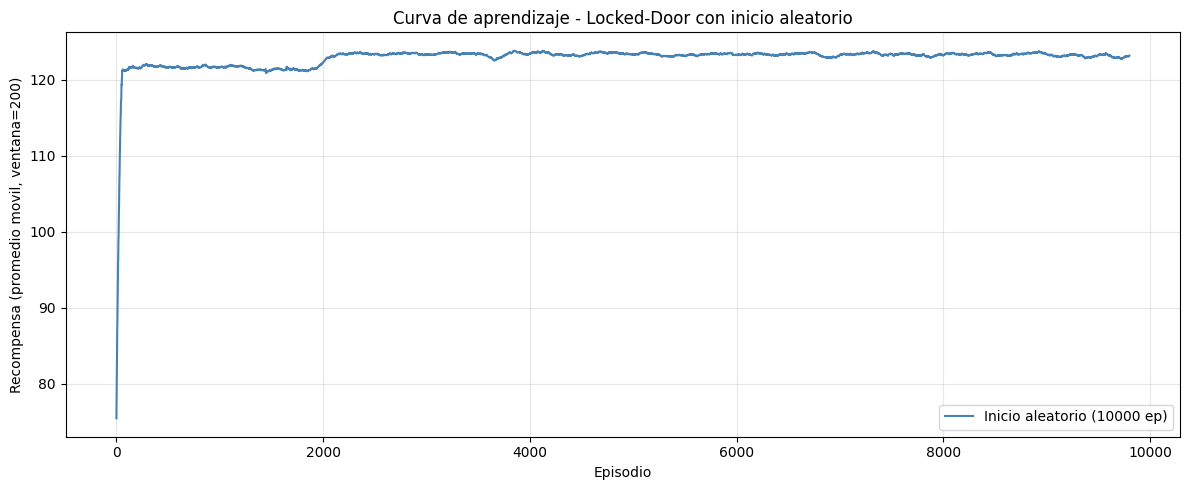

In [34]:
# --- Curvas de aprendizaje comparativas ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(moving_average(rewards_rand, 200), color='steelblue', label='Inicio aleatorio (10000 ep)')
ax.set_xlabel('Episodio')
ax.set_ylabel('Recompensa (promedio movil, ventana=200)')
ax.set_title('Curva de aprendizaje - Locked-Door con inicio aleatorio')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Escenario 3.2: Llaves de distintos colores en posiciones aleatorias

**Problema:** Si el agente fue entrenado con la llave en una posicion fija `(1,3)`, no puede adaptarse a llaves en posiciones diferentes, porque esos estados nunca fueron visitados durante entrenamiento.

**Solucion:** Extender el estado para incluir la posicion de la llave:
`(fila, col, tiene_bola, tiene_llave, puerta_abierta, llave_fila, llave_col)`

Esto se implementa en `locked_door_extended.py`.

In [35]:
from locked_door_extended import LockedDoorExtended

key_positions = [(0, 0), (0, 3), (1, 3), (2, 1), (3, 0), (1, 1), (2, 3)]

np.random.seed(42)
env_ext = LockedDoorExtended(key_positions=key_positions, randomize_start=True)
print(f"Espacio de estados extendido: {len(env_ext.get_states())}")
print(f"Acciones: {env_ext.actions}")
print(f"Posiciones posibles de la llave: {key_positions}")

agent_ext = QLearning(env_ext, alpha=0.1, gamma=0.99, epsilon=0.9, num_episodes=20000)
rewards_ext = agent_ext.run()

print(f"\nRecompensa promedio (ultimos 100): {np.mean(rewards_ext[-100:]):.1f}")
agent_ext.save_q_table("q_table_extended.json")

Espacio de estados extendido: 2856
Acciones: ['up', 'down', 'left', 'right', 'pick_up', 'open_door']
Posiciones posibles de la llave: [(0, 0), (0, 3), (1, 3), (2, 1), (3, 0), (1, 1), (2, 3)]


2026-03-25 20:25:25.191 | INFO     | q_learning:run:100 - Episode 100/20000 - Avg Reward (last 100): -224.6 - Steps: 47
2026-03-25 20:25:25.320 | INFO     | q_learning:run:100 - Episode 200/20000 - Avg Reward (last 100): 1.5 - Steps: 57
2026-03-25 20:25:25.377 | INFO     | q_learning:run:100 - Episode 300/20000 - Avg Reward (last 100): 86.1 - Steps: 15
2026-03-25 20:25:25.407 | INFO     | q_learning:run:100 - Episode 400/20000 - Avg Reward (last 100): 113.0 - Steps: 15
2026-03-25 20:25:25.432 | INFO     | q_learning:run:100 - Episode 500/20000 - Avg Reward (last 100): 118.1 - Steps: 21
2026-03-25 20:25:25.456 | INFO     | q_learning:run:100 - Episode 600/20000 - Avg Reward (last 100): 118.9 - Steps: 16
2026-03-25 20:25:25.479 | INFO     | q_learning:run:100 - Episode 700/20000 - Avg Reward (last 100): 120.6 - Steps: 14
2026-03-25 20:25:25.500 | INFO     | q_learning:run:100 - Episode 800/20000 - Avg Reward (last 100): 121.9 - Steps: 19
2026-03-25 20:25:25.522 | INFO     | q_learning:ru


Recompensa promedio (ultimos 100): 123.2


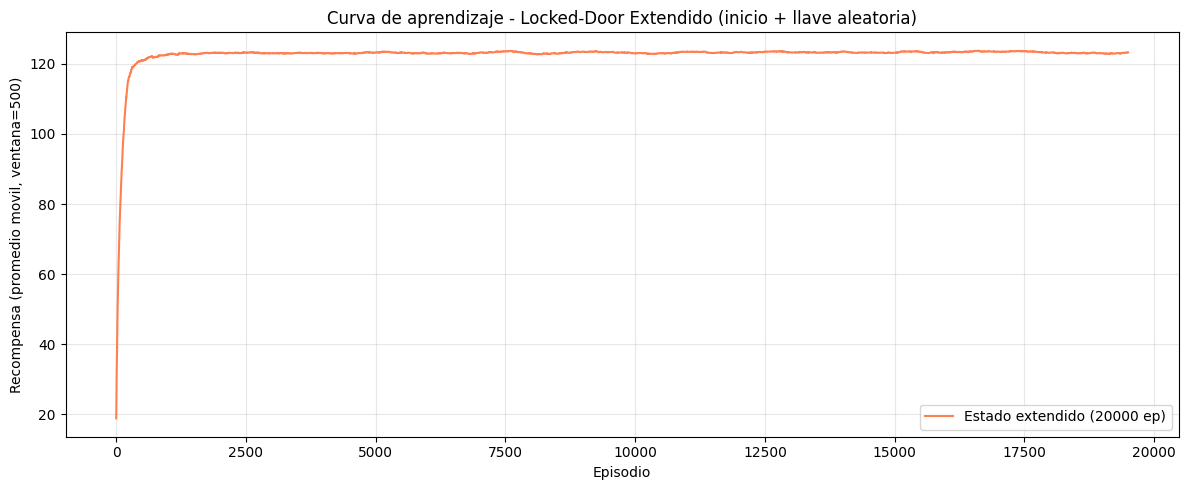

In [36]:
# --- Curva de aprendizaje del agente extendido ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(moving_average(rewards_ext, 500), color='coral', label='Estado extendido (20000 ep)')
ax.set_xlabel('Episodio')
ax.set_ylabel('Recompensa (promedio movil, ventana=500)')
ax.set_title('Curva de aprendizaje - Locked-Door Extendido (inicio + llave aleatoria)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
# --- Evaluacion del agente extendido ---
print("Evaluacion del agente extendido:")
print("=" * 65)

test_configs = [
    ((2, 0), (1, 3)),
    ((2, 0), (0, 0)),
    ((0, 0), (2, 1)),
    ((3, 0), (0, 3)),
    ((1, 1), (3, 0)),
    ((0, 3), (2, 3)),
]

for start, kp in test_configs:
    env_ext.agent_start = start
    env_ext.key_pos = kp
    env_ext.current_state = (start[0], start[1], False, False, False, kp[0], kp[1])
    agent_ext.epsilon = 1.0
    state = env_ext.get_current_state()
    steps = 0
    while not env_ext.is_terminal() and steps < 50:
        action = agent_ext.choose_action(state)
        _, new_state = env_ext.do_action(action)
        state = new_state
        steps += 1
    reached = env_ext.is_terminal()
    print(f"  Inicio {start}, Llave en {kp}: {'EXITO' if reached else 'FALLO'} en {steps} pasos")

Evaluacion del agente extendido:
  Inicio (2, 0), Llave en (1, 3): EXITO en 17 pasos
  Inicio (2, 0), Llave en (0, 0): EXITO en 19 pasos
  Inicio (0, 0), Llave en (2, 1): EXITO en 17 pasos
  Inicio (3, 0), Llave en (0, 3): EXITO en 22 pasos
  Inicio (1, 1), Llave en (3, 0): EXITO en 19 pasos
  Inicio (0, 3), Llave en (2, 3): EXITO en 14 pasos


### Prueba con llave de color incorrecto

=== Prueba: llave de color incorrecto (puerta azul, llave roja) ===



2026-03-25 20:25:30.812 | INFO     | q_learning:run:100 - Episode 100/3000 - Avg Reward (last 100): -989.2 - Steps: 1000
2026-03-25 20:25:31.677 | INFO     | q_learning:run:100 - Episode 200/3000 - Avg Reward (last 100): -989.1 - Steps: 1000
2026-03-25 20:25:32.480 | INFO     | q_learning:run:100 - Episode 300/3000 - Avg Reward (last 100): -989.2 - Steps: 1000
2026-03-25 20:25:33.301 | INFO     | q_learning:run:100 - Episode 400/3000 - Avg Reward (last 100): -989.0 - Steps: 1000
2026-03-25 20:25:34.164 | INFO     | q_learning:run:100 - Episode 500/3000 - Avg Reward (last 100): -989.1 - Steps: 1000
2026-03-25 20:25:35.014 | INFO     | q_learning:run:100 - Episode 600/3000 - Avg Reward (last 100): -989.0 - Steps: 1000
2026-03-25 20:25:35.829 | INFO     | q_learning:run:100 - Episode 700/3000 - Avg Reward (last 100): -989.0 - Steps: 1000
2026-03-25 20:25:36.631 | INFO     | q_learning:run:100 - Episode 800/3000 - Avg Reward (last 100): -989.0 - Steps: 1000
2026-03-25 20:25:37.467 | INFO  

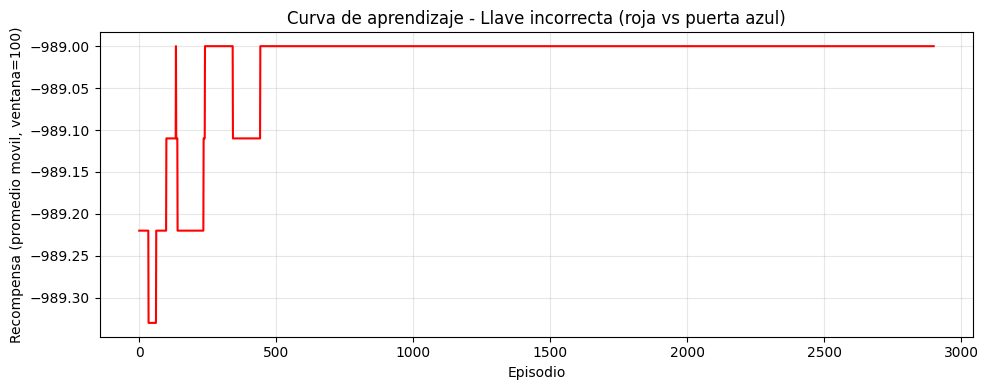


Recompensa promedio (ultimos 100): -989.0
Resultado: El agente NO puede completar la tarea.
La llave roja no puede abrir la puerta azul, por lo que el agente
nunca puede cruzar a la habitacion derecha.


In [38]:
# --- Prueba: llave de color incorrecto ---
print("=== Prueba: llave de color incorrecto (puerta azul, llave roja) ===")
print()

np.random.seed(42)
env_wrong = LockedDoorEnv(key_color='red')
agent_wrong = QLearning(env_wrong, alpha=0.1, gamma=0.99, epsilon=0.9, num_episodes=3000)
rewards_wrong = agent_wrong.run()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(moving_average(rewards_wrong, 100), color='red')
ax.set_xlabel('Episodio')
ax.set_ylabel('Recompensa (promedio movil, ventana=100)')
ax.set_title('Curva de aprendizaje - Llave incorrecta (roja vs puerta azul)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nRecompensa promedio (ultimos 100): {np.mean(rewards_wrong[-100:]):.1f}")
print("Resultado: El agente NO puede completar la tarea.")
print("La llave roja no puede abrir la puerta azul, por lo que el agente")
print("nunca puede cruzar a la habitacion derecha.")

## Analisis - Task 3

### Escenario 3.1 - Inicio aleatorio

**Problema:** El agente original (entrenado desde una posicion fija `(2,0)`) falla desde posiciones no visitadas. Esto ocurre porque Q-Learning tabular no tiene Q-valores para estados que nunca fueron explorados durante entrenamiento.

**Solucion:** Entrenar con posiciones de inicio aleatorias. Al explorar desde todas las posiciones del cuarto izquierdo, el agente aprende una politica general que funciona desde cualquier punto. El costo es un mayor numero de episodios necesarios (10000 vs 5000).

### Escenario 3.2 - Llaves en posiciones aleatorias

**Problema:** El estado original `(fila, col, tiene_bola, tiene_llave, puerta_abierta)` no codifica *donde* esta la llave. Si la llave cambia de posicion, el agente no sabe a donde ir a buscarla.

**Solucion:** Extender el estado para incluir la posicion de la llave: `(fila, col, tiene_bola, tiene_llave, puerta_abierta, llave_fila, llave_col)`. Esto aumenta el espacio de estados significativamente pero permite al agente aprender a buscar la llave en diferentes posiciones.

### Llave de color incorrecto

Cuando la unica llave disponible es del color equivocado, el problema **no tiene solucion**. El agente recoge la bola pero nunca puede recoger la llave roja (porque no coincide con la puerta azul), y por lo tanto nunca puede abrir la puerta. La curva de aprendizaje muestra que la recompensa se estanca en valores negativos.

---
# Conclusiones
---

1. **Q-Learning es un metodo off-policy efectivo** que aprende la politica optima independientemente de la politica de exploracion. En Cliff-Walk, esto se traduce en aprender el camino mas corto (al borde del barranco), mientras que SARSA (on-policy) aprende un camino mas seguro.

2. **La diferencia clave entre SARSA y Q-Learning** radica en la regla de actualizacion: SARSA usa $Q(s', a')$ donde $a'$ es la accion realmente tomada (incorpora el riesgo de exploracion), mientras que Q-Learning usa $\max_{a'} Q(s', a')$ (asume la mejor accion posible). Durante entrenamiento SARSA es mas seguro; en explotacion Q-Learning es superior.

3. **Las recompensas intermedias son fundamentales** para problemas con sub-objetivos (Locked-Door). Sin ellas, el agente enfrenta un problema de recompensa escasa que hace el aprendizaje extremadamente lento con metodos tabulares.

4. **Q-Learning tabular no generaliza a estados no visitados.** Esta es su limitacion fundamental: para adaptarse a variabilidad en el ambiente (posicion de inicio, posicion de objetos), se necesita:
   - Entrenar con variabilidad (inicio aleatorio, posiciones aleatorias)
   - Extender el estado para capturar la informacion relevante
   - Para ambientes con alta variabilidad, metodos de aproximacion de funciones (e.g., Deep Q-Learning) serian necesarios para interpolar entre estados similares.

5. **La representacion del estado determina la capacidad del agente.** Al extender el estado para incluir la posicion de la llave, el agente puede aprender a buscarla en diferentes ubicaciones. Sin embargo, esto incrementa exponencialmente el espacio de estados y los episodios necesarios para convergencia.